# Bayesian GARCH(1,1) : Random Walk Metropolis Sampler

### Reference  
Following the model and priors described in:  
Mira, Solgi & Imparato (2013) *"Zero variance Markov chain Monte Carlo for Bayesian estimators"*, Statistics and Computing 23:653–662.

## Model

$$
y_t = \sqrt{h_t} \cdot \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1) \; (\text{or Student-t})
$$

$$
h_t = \omega + \alpha \, y_{t-1}^2 + \beta \, h_{t-1}
$$

Note: What we have labeled alpha and beta correspond to omega1 and omega2 in the first paper

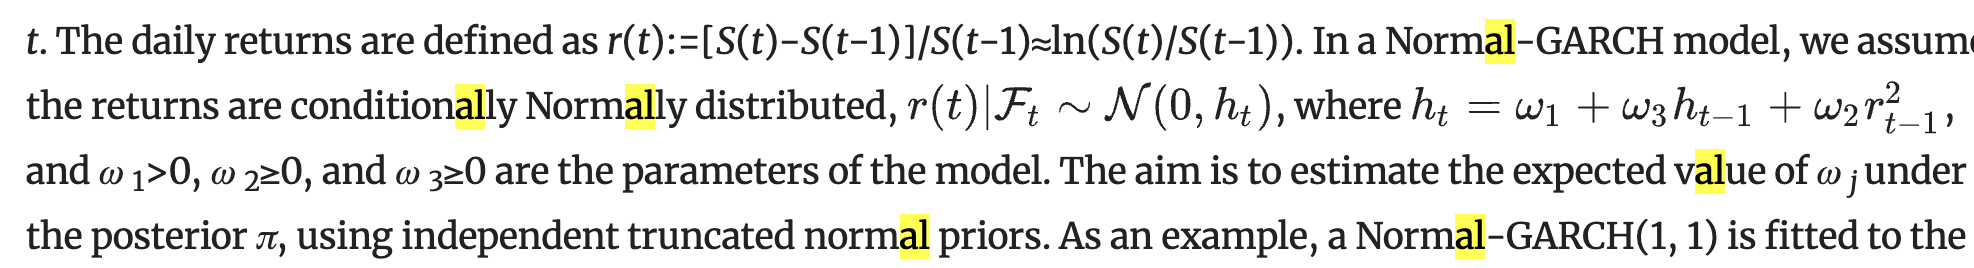

## Parameters

$$
\theta = (\omega, \alpha, \beta)
$$

### Constraints

$$
\omega > 0
$$

$$
\alpha \geq 0
$$

$$
\beta \geq 0
$$

$$
\alpha + \beta < 1
$$

## Prior Distribution

(Ardia 2008 / Nakatsuma 2000 setup)

$$
p(\omega) \propto \frac{1}{\omega}
$$

*(log-uniform / Jeffreys-type prior)*  

$$
\alpha \sim \mathcal{U}(0,1)
$$

$$
\beta \sim \mathcal{U}(0,1)
$$

Subject to:

$$
\alpha + \beta < 1
$$

## Log-Posterior (up to a constant)

$$
\log \pi(\theta \mid y) = \log L(\theta; y) + \log p(\theta)
$$

## Random Walk Metropolis Algorithm

### Proposal

$$
\theta^* = \theta + \delta, \quad \delta \sim \mathcal{N}(0, \Sigma)
$$

$$
\Sigma \text{ is tuned to achieve an acceptance rate of approximately } 23\%
$$

(rule of thumb from Gelman et al.)

### Practical Implementation

Sampling in transformed (unconstrained) space:

$$
\log \omega
$$

$$
\text{logit}(\alpha)
$$

$$
\text{logit}(\beta)
$$

Then map back to the original parameter space to enforce constraints.

# 1.  GARCH(1,1) utilities

In [2]:
# ─────────────────────────────────────────────────────────────
#  1.  GARCH(1,1) utilities
# ─────────────────────────────────────────────────────────────

def garch_variances(y, omega, alpha, beta):
    """Recursively compute conditional variances h_t."""
    T = len(y)
    h = np.empty(T)
    h[0] = np.var(y)           # initialise at sample variance
    for t in range(1, T):
        h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
    return h


def log_likelihood(y, omega, alpha, beta):
    """Gaussian GARCH(1,1) log-likelihood (sum over t=1..T)."""
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return -np.inf
    h = garch_variances(y, omega, alpha, beta)
    # avoid numerical issues
    if np.any(h <= 0):
        return -np.inf
    return -0.5 * np.sum(np.log(h) + y**2 / h)


def log_prior(omega, alpha, beta):
    """Log-prior: log-uniform on omega, Uniform on alpha & beta,
    with the stationarity constraint alpha+beta < 1."""
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return -np.inf
    # log p(omega) ∝ -log(omega)   (Jeffreys prior)
    return -np.log(omega)


def log_posterior(y, omega, alpha, beta):
    lp = log_prior(omega, alpha, beta)
    if not np.isfinite(lp):
        return -np.inf
    return log_likelihood(y, omega, alpha, beta) + lp

# Parameter transformations  (constrained → unconstrained)

In [3]:
# ─────────────────────────────────────────────────────────────
#  2.  Parameter transformations  (constrained → unconstrained)
# ─────────────────────────────────────────────────────────────
# theta = (omega, alpha, beta)   constrained
# phi   = (log_omega, logit_alpha, logit_beta_given_alpha)  unconstrained
#
# alpha  = sigmoid(phi[1])
# beta   = (1-alpha) * sigmoid(phi[2])   ensures alpha+beta < 1

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def logit(p):
    return np.log(p / (1.0 - p))

def phi_to_theta(phi):
    """Unconstrained → constrained."""
    log_omega, phi_alpha, phi_beta = phi
    omega = np.exp(log_omega)
    alpha = sigmoid(phi_alpha)
    beta  = (1.0 - alpha) * sigmoid(phi_beta)
    return omega, alpha, beta

def theta_to_phi(omega, alpha, beta):
    """Constrained → unconstrained."""
    log_omega = np.log(omega)
    phi_alpha = logit(alpha)
    phi_beta  = logit(beta / (1.0 - alpha))
    return np.array([log_omega, phi_alpha, phi_beta])

def log_jacobian(phi):
    """
    Log |∂theta/∂phi| for the change of variables.
    Needed so the RWM in phi-space targets the right posterior.
    """
    _, phi_alpha, phi_beta = phi
    alpha = sigmoid(phi_alpha)
    s_b   = sigmoid(phi_beta)
    # d(omega)/d(log_omega) = omega
    # d(alpha)/d(phi_alpha) = alpha*(1-alpha)
    # d(beta)/d(phi_beta)   = (1-alpha)*s_b*(1-s_b)
    log_J = (phi[0]                          # log omega
             + np.log(alpha*(1-alpha))        # dalpha/dphi_alpha
             + np.log((1-alpha)*s_b*(1-s_b))) # dbeta/dphi_beta
    return log_J

def log_posterior_transformed(y, phi):
    """Log-posterior in unconstrained space (includes Jacobian)."""
    omega, alpha, beta = phi_to_theta(phi)
    lp = log_posterior(y, omega, alpha, beta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_jacobian(phi)

# 3.  Random Walk Metropolis sampler

In [4]:
# ─────────────────────────────────────────────────────────────
#  3.  Random Walk Metropolis sampler
# ─────────────────────────────────────────────────────────────

def rwm_garch(y, n_iter=50_000, burn_in=10_000, sigma_prop=None,
              seed=42, verbose=True):
    """
    Random Walk Metropolis for the GARCH(1,1) posterior.
    Sampling is done in the unconstrained (phi) space.

    Parameters
    ----------
    y         : array-like, log-returns
    n_iter    : total MCMC iterations (including burn-in)
    burn_in   : number of draws to discard
    sigma_prop: proposal standard deviations (len-3 array).
                If None, auto-tuned via a short pilot run.
    seed      : random seed
    verbose   : print acceptance rate and progress

    Returns
    -------
    samples   : dict with arrays 'omega','alpha','beta' (post burn-in)
    accept_rate: float
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)

    # ── Starting values: rough MLE-style initialisation ──
    omega0 = np.var(y) * 0.05
    alpha0 = 0.10
    beta0  = 0.85
    phi_cur = theta_to_phi(omega0, alpha0, beta0)
    lp_cur  = log_posterior_transformed(y, phi_cur)

    # ── Proposal covariance (diagonal) ──
    if sigma_prop is None:
        # Pilot run of 2000 iterations with wide steps to estimate scale
        sigma_prop = np.array([0.05, 0.10, 0.10])
        if verbose:
            print("Running pilot to calibrate proposal ...")
        sigma_prop = _calibrate_proposal(y, phi_cur, sigma_prop,
                                         rng, n_pilot=3000)
        if verbose:
            print(f"  Calibrated σ_prop = {sigma_prop.round(4)}")

    # ── Main chain ──
    chain = np.empty((n_iter, 3))
    n_accept = 0

    for i in range(n_iter):
        # Proposal
        phi_prop = phi_cur + sigma_prop * rng.standard_normal(3)
        lp_prop  = log_posterior_transformed(y, phi_prop)

        # Metropolis ratio (symmetric proposal → only posterior ratio)
        log_alpha_mh = lp_prop - lp_cur
        if np.log(rng.uniform()) < log_alpha_mh:
            phi_cur = phi_prop
            lp_cur  = lp_prop
            n_accept += 1

        chain[i] = phi_to_theta(phi_cur)

        if verbose and (i+1) % 10_000 == 0:
            ar = n_accept / (i+1)
            print(f"  Iter {i+1:>6d}  accept = {ar:.3f}")

    accept_rate = n_accept / n_iter
    samples = {
        'omega': chain[burn_in:, 0],
        'alpha': chain[burn_in:, 1],
        'beta' : chain[burn_in:, 2],
    }
    return samples, accept_rate


def _calibrate_proposal(y, phi_start, sigma_init, rng, n_pilot=3000,
                        target_ar=0.23):
    """Simple adaptive scaling: adjust σ to hit ~23% acceptance rate."""
    sigma = sigma_init.copy()
    phi_cur = phi_start.copy()
    lp_cur  = log_posterior_transformed(y, phi_cur)
    n_accept = 0
    for i in range(n_pilot):
        phi_prop = phi_cur + sigma * rng.standard_normal(3)
        lp_prop  = log_posterior_transformed(y, phi_prop)
        if np.log(rng.uniform()) < lp_prop - lp_cur:
            phi_cur = phi_prop
            lp_cur  = lp_prop
            n_accept += 1
        # Adapt every 500 iterations
        if (i+1) % 500 == 0:
            ar = n_accept / (i+1)
            sigma *= np.exp(ar - target_ar)   # simple Robbins-Monro step
    return sigma

## First, using simulated data


MCMC DIAGNOSTICS (SIMULATED)
Acceptance rate: 0.20046
omega: mean=0.0430, std=0.0088, ESS≈324.7
alpha: mean=0.0922, std=0.0117, ESS≈912.2
beta: mean=0.8205, std=0.0253, ESS≈358.8


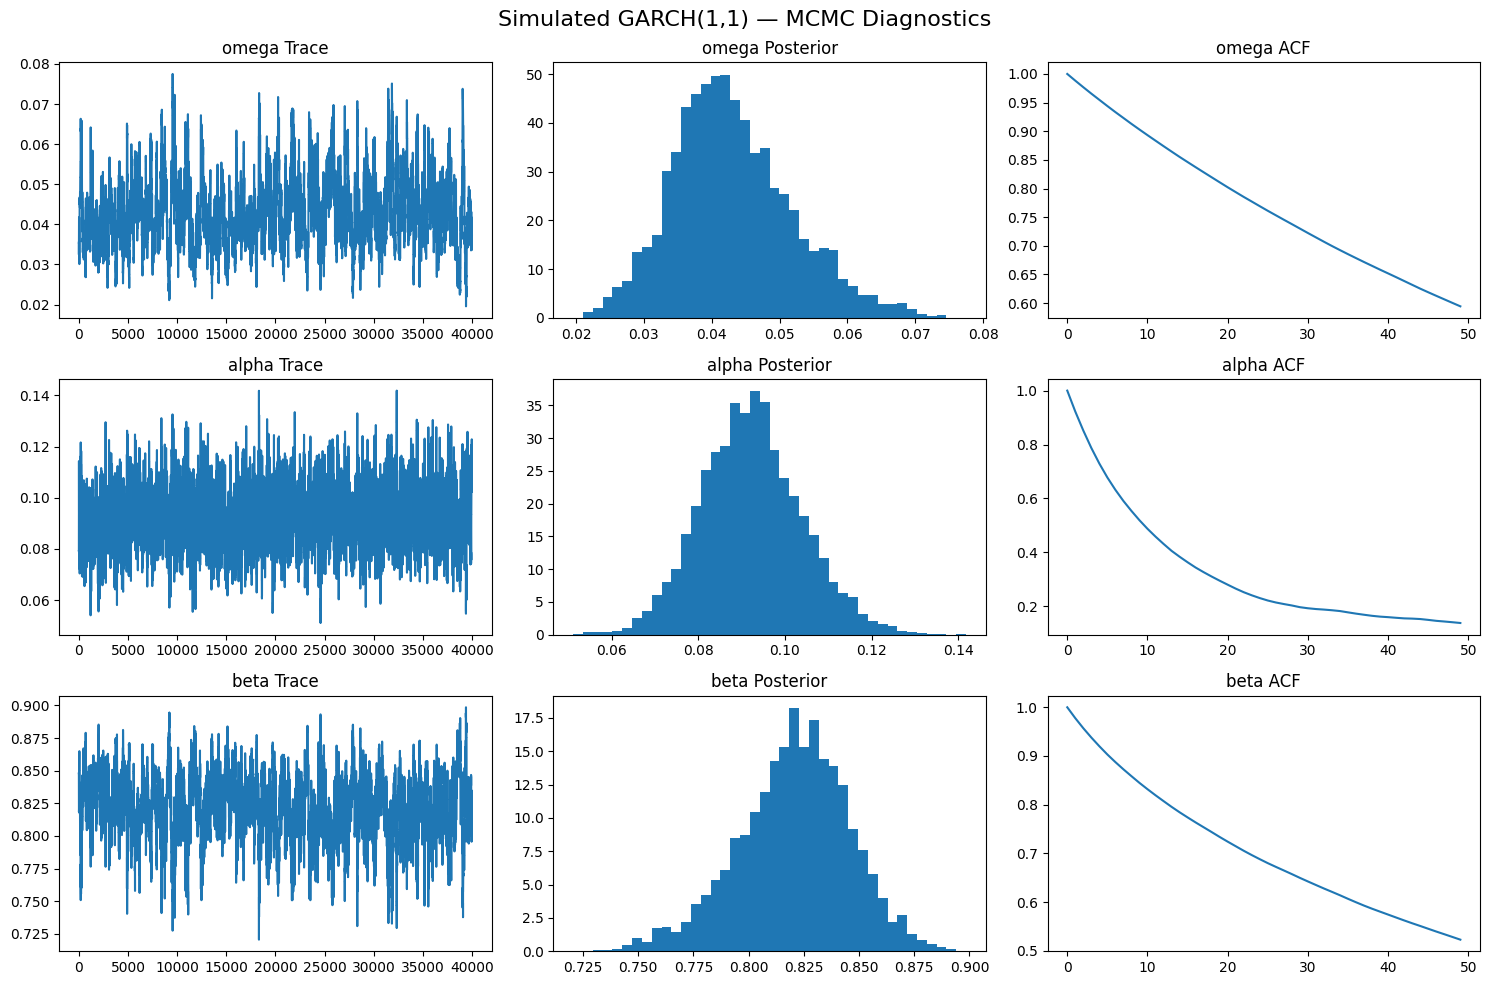


RESIDUAL DIAGNOSTICS
Mean: -0.004284695189473794
Std: 0.9985414942223072


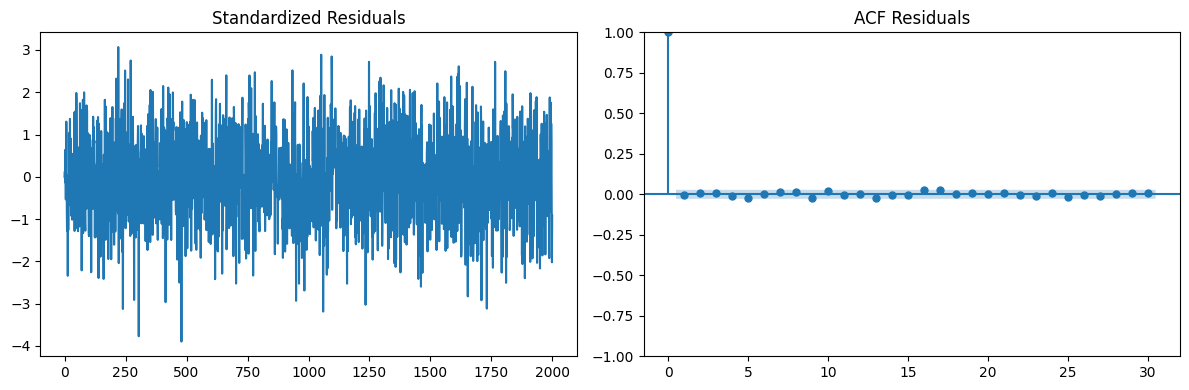


Log-likelihood: -611.3063428554403


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

# ─────────────────────────────
# Simulation GARCH(1,1)
# ─────────────────────────────
def simulate_garch(T=5000, omega=0.05, alpha=0.1, beta=0.80, seed=0):
    rng = np.random.default_rng(seed)
    y = np.zeros(T)
    h = np.zeros(T)
    h[0] = omega / (1 - alpha - beta)
    for t in range(1, T):
        h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
        y[t] = rng.normal(0, np.sqrt(h[t]))
    return y

# ─────────────────────────────
# ESS
# ─────────────────────────────
def autocorr(x, lag):
    return np.corrcoef(x[:-lag], x[lag:])[0,1]

def ess(x, max_lag=100):
    rho = np.array([autocorr(x, k) for k in range(1, max_lag)])
    return len(x) / (1 + 2*np.nansum(rho))


# ─────────────────────────────
# GARCH variance reconstruction
# ─────────────────────────────
def compute_garch_variance(y, omega, alpha, beta):
    T = len(y)
    h = np.zeros(T)
    h[0] = omega / (1 - alpha - beta)
    for t in range(1, T):
        h[t] = omega + alpha*y[t-1]**2 + beta*h[t-1]
    return h


# ─────────────────────────────
# FULL DIAGNOSTIC PLOT (ONE FIGURE)
# ─────────────────────────────
def plot_full_diagnostics(samples, title=""):
    params = ["omega", "alpha", "beta"]
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    
    for i, p in enumerate(params):
        x = samples[p]
        
        # Trace
        axes[i,0].plot(x)
        axes[i,0].set_title(f"{p} Trace")
        
        # Posterior
        axes[i,1].hist(x, bins=40, density=True)
        axes[i,1].set_title(f"{p} Posterior")
        
        # ACF
        lags = 50
        acf_vals = [np.corrcoef(x[:-k], x[k:])[0,1] if k>0 else 1 for k in range(lags)]
        axes[i,2].plot(acf_vals)
        axes[i,2].set_title(f"{p} ACF")
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────
# RUN SIMULATION + MCMC
# ─────────────────────────────
y_sim = simulate_garch()

samples_sim, ar_sim = rwm_garch(y_sim, verbose=False)

print("\n==============================")
print("MCMC DIAGNOSTICS (SIMULATED)")
print("==============================")
print("Acceptance rate:", ar_sim)


# ─────────────────────────────
# PARAMETER SUMMARY + ESS
# ─────────────────────────────
for k in samples_sim:
    print(f"{k}: mean={np.mean(samples_sim[k]):.4f}, std={np.std(samples_sim[k]):.4f}, ESS≈{ess(samples_sim[k]):.1f}")


# ─────────────────────────────
# FULL MCMC PLOTS (SIMULATED)
# ─────────────────────────────
plot_full_diagnostics(samples_sim, "Simulated GARCH(1,1) — MCMC Diagnostics")


# ─────────────────────────────
# POINT ESTIMATES
# ─────────────────────────────
omega_hat = np.mean(samples_sim["omega"])
alpha_hat = np.mean(samples_sim["alpha"])
beta_hat  = np.mean(samples_sim["beta"])


# ─────────────────────────────
# GARCH FIT + RESIDUALS
# ─────────────────────────────
h_est = compute_garch_variance(y_sim, omega_hat, alpha_hat, beta_hat)
residuals = y_sim / np.sqrt(h_est)


print("\n==============================")
print("RESIDUAL DIAGNOSTICS")
print("==============================")
print("Mean:", np.mean(residuals))
print("Std:", np.std(residuals))


# ─────────────────────────────
# RESIDUAL PLOTS (ONE FIGURE)
# ─────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(residuals[:2000])
ax[0].set_title("Standardized Residuals")

sm.graphics.tsa.plot_acf(residuals, lags=30, ax=ax[1])
ax[1].set_title("ACF Residuals")

plt.tight_layout()
plt.show()


# ─────────────────────────────
# LOG-LIKELIHOOD
# ─────────────────────────────
def loglik_garch(y, omega, alpha, beta):
    h = compute_garch_variance(y, omega, alpha, beta)
    return -0.5*np.sum(np.log(h) + y**2 / h)

ll = loglik_garch(y_sim, omega_hat, alpha_hat, beta_hat)

print("\nLog-likelihood:", ll)

## Second, using real exchange rate data

/Users/mathiaspisch/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed



REAL DATA (JPY/USD)
Acceptance rate: 0.14022
omega: mean=0.0000, std=0.0000, ESS≈705.2
alpha: mean=0.0765, std=0.0119, ESS≈1705.7
beta: mean=0.9094, std=0.0141, ESS≈1046.0


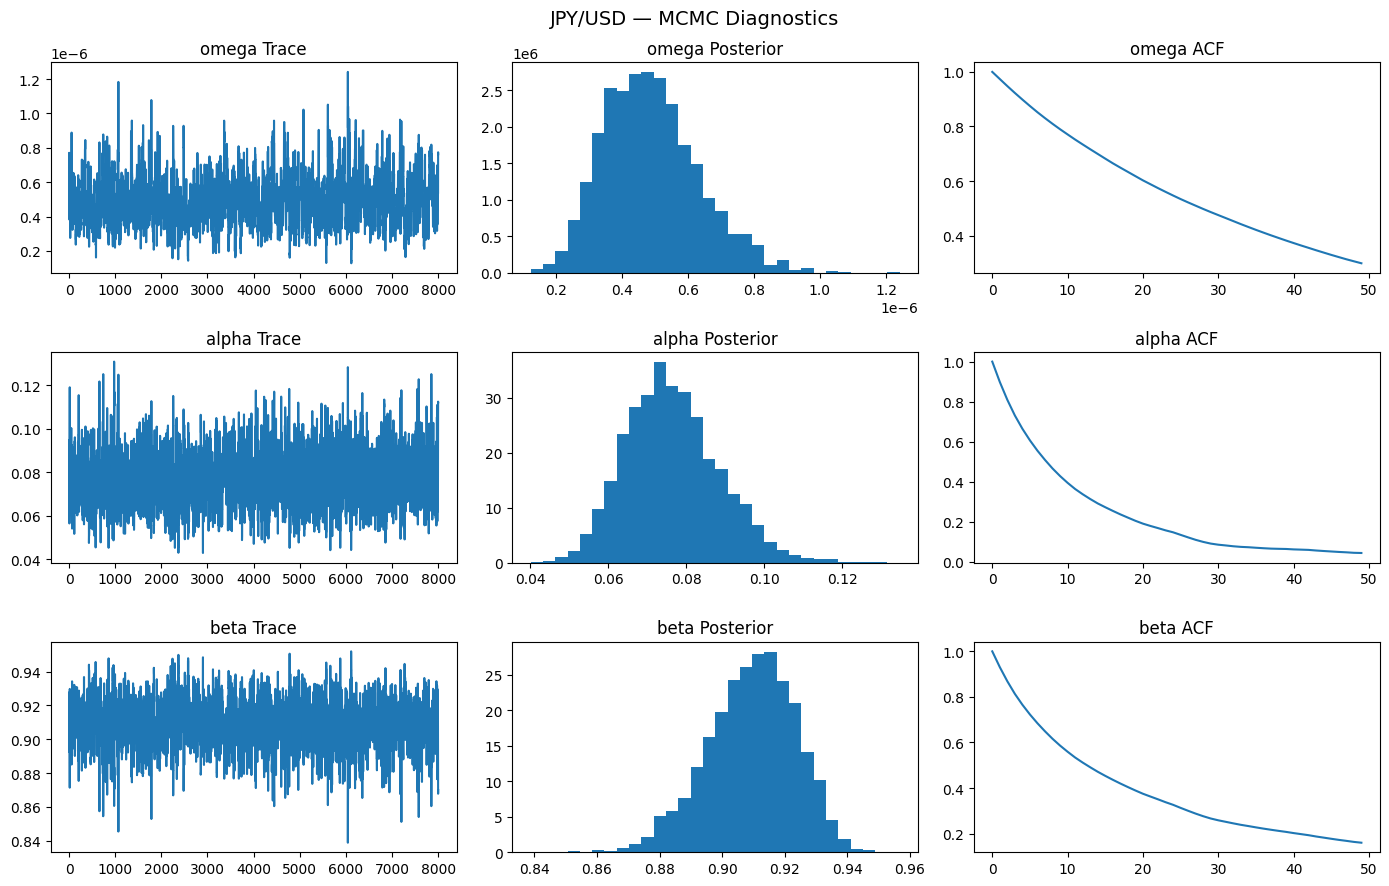


Residual diagnostics
Mean: 0.015253017457344892
Std: 0.9984599733002482
Jarque-Bera: SignificanceResult(statistic=np.float64(331.8629750513084), pvalue=np.float64(8.647102233504462e-73))


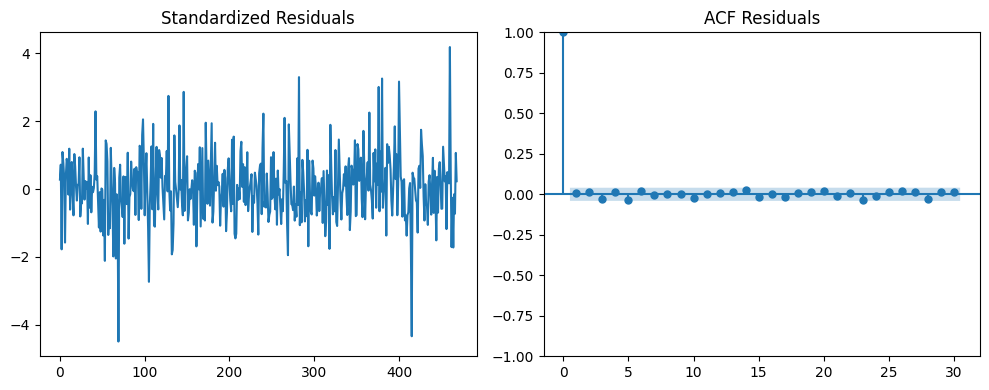

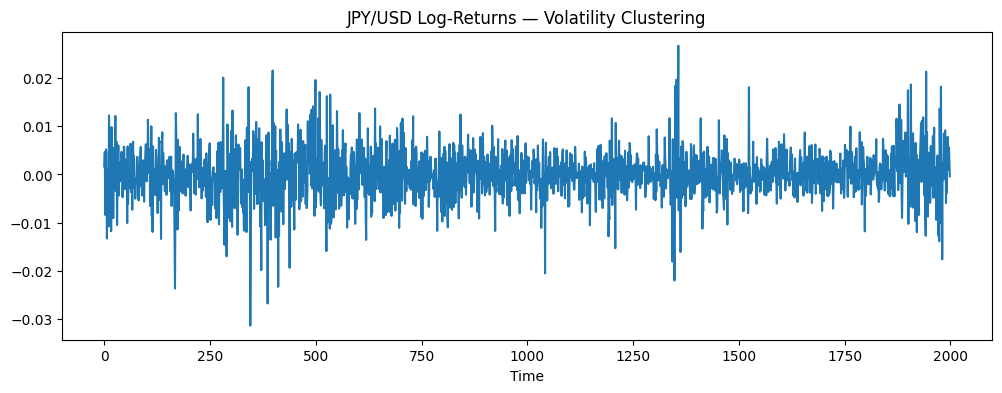

Log-likelihood: 11218.792885153362


In [6]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

# ─────────────────────────────
# DATA (JPY/USD)
# ─────────────────────────────
ticker = "JPY=X"
data = yf.download(ticker, start="2015-01-01", end="2024-01-01")

prices = data["Close"][ticker].dropna()
y_real = np.diff(np.log(prices.values))


# ─────────────────────────────
# MCMC
# ─────────────────────────────
samples_real, ar_real = rwm_garch(y_real, verbose=False)

print("\n==============================")
print("REAL DATA (JPY/USD)")
print("==============================")
print("Acceptance rate:", ar_real)


# ─────────────────────────────
# FAST ACF
# ─────────────────────────────
def fast_acf(x, nlags=50):
    x = x - np.mean(x)
    denom = np.dot(x, x)
    return np.array([
        np.dot(x[:-k or None], x[k:]) / denom
        for k in range(nlags)
    ])


# ─────────────────────────────
# FAST ESS
# ─────────────────────────────
def ess_fast(x, nlags=50):
    rho = fast_acf(x)[1:]
    return len(x) / (1 + 2*np.sum(rho))


# ─────────────────────────────
# SUMMARY
# ─────────────────────────────
for k in samples_real:
    x = samples_real[k]
    print(f"{k}: mean={x.mean():.4f}, std={x.std():.4f}, ESS≈{ess_fast(x):.1f}")


# ─────────────────────────────
# FAST DIAGNOSTIC PLOTS
# ─────────────────────────────
def plot_full(samples, title=""):
    params = ["omega", "alpha", "beta"]

    fig, axes = plt.subplots(3, 3, figsize=(14, 9))

    for i, p in enumerate(params):
        x = samples[p]

        # Trace (downsample for speed)
        axes[i,0].plot(x[::5])
        axes[i,0].set_title(f"{p} Trace")

        # Posterior
        axes[i,1].hist(x, bins=30, density=True)
        axes[i,1].set_title(f"{p} Posterior")

        # ACF
        axes[i,2].plot(fast_acf(x))
        axes[i,2].set_title(f"{p} ACF")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_full(samples_real, "JPY/USD — MCMC Diagnostics")


# ─────────────────────────────
# VOLATILITY ESTIMATION
# ─────────────────────────────
omega_hat = samples_real["omega"].mean()
alpha_hat = samples_real["alpha"].mean()
beta_hat  = samples_real["beta"].mean()


def compute_garch_variance(y, omega, alpha, beta):
    h = np.zeros_like(y)
    h[0] = omega / (1 - alpha - beta)
    for t in range(1, len(y)):
        h[t] = omega + alpha*y[t-1]**2 + beta*h[t-1]
    return h


h = compute_garch_variance(y_real, omega_hat, alpha_hat, beta_hat)
res = y_real / np.sqrt(h)


# ─────────────────────────────
# RESIDUAL DIAGNOSTICS
# ─────────────────────────────
print("\nResidual diagnostics")
print("Mean:", res.mean())
print("Std:", res.std())
print("Jarque-Bera:", stats.jarque_bera(res))


# ─────────────────────────────
# RESIDUAL PLOTS
# ─────────────────────────────
fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].plot(res[::5])
ax[0].set_title("Standardized Residuals")

sm.graphics.tsa.plot_acf(res, lags=30, ax=ax[1])
ax[1].set_title("ACF Residuals")

plt.tight_layout()
plt.show()


# ─────────────────────────────
# VOLATILITY CLUSTERING (IMPORTANT FIGURE)
# ─────────────────────────────
plt.figure(figsize=(12,4))
plt.plot(y_real[:2000])
plt.title("JPY/USD Log-Returns — Volatility Clustering")
plt.xlabel("Time")
plt.show()


# ─────────────────────────────
# LOG-LIKELIHOOD
# ─────────────────────────────
def loglik(y, w, a, b):
    h = compute_garch_variance(y, w, a, b)
    return -0.5*np.sum(np.log(h) + y**2 / h)

print("Log-likelihood:", loglik(y_real, omega_hat, alpha_hat, beta_hat))